<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Copy_of_Akash_Ontology_Code001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from transformers import OpenAIGPTModel

# Load the original pre-trained GPT-1 model weights
model = OpenAIGPTModel.from_pretrained('openai-gpt')

# Extract the Token Embedding Matrix (wte)
token_embeddings = model.tokens_embed.weight.detach()

print(f"Matrix Shape: {token_embeddings.shape}")  # Outputs: torch.Size([40478, 768])

# Print an actual 3x5 sample slice from the top-left corner of the matrix
print("\nActual Weight Sample Slice:")
print(token_embeddings[:10, :10])

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] OpenAIGPTModel LOAD REPORT from: openai-gpt
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Matrix Shape: torch.Size([40478, 768])

Actual Weight Sample Slice:
tensor([[ 0.0464, -0.1280, -0.0153,  0.0641, -0.0497, -0.0210,  0.1288,  0.0593,
         -0.0790, -0.0448],
        [ 0.0762, -0.0894,  0.0799,  0.1233,  0.0443, -0.0030,  0.0703, -0.0445,
          0.0616, -0.0958],
        [-0.0694, -0.0964, -0.0466,  0.0339, -0.0950,  0.0895,  0.1472, -0.0660,
         -0.0285, -0.1261],
        [-0.0748,  0.0645, -0.1135,  0.0328,  0.0025,  0.0701,  0.0946, -0.0134,
         -0.0144, -0.0410],
        [ 0.0591,  0.0095, -0.0060,  0.1532,  0.0787, -0.0353,  0.0979,  0.0539,
          0.0710, -0.0901],
        [-0.1431, -0.0685, -0.1192,  0.0381,  0.0723, -0.0051,  0.2048,  0.0866,
          0.0621, -0.0653],
        [-0.0638, -0.0946, -0.0498,  0.0421, -0.0961,  0.0874,  0.1415, -0.0489,
         -0.0320, -0.1252],
        [-0.0982,  0.0511, -0.0096, -0.0280, -0.0586, -0.0365,  0.1212,  0.0519,
         -0.0419,  0.0370],
        [-0.0197,  0.0202, -0.1055, -0.1183, -0.0298, -0.015

In [ ]:
import torch
from transformers import OpenAIGPTTokenizer, OpenAIGPTModel

# -------------------------------
# Input Text
# -------------------------------
text = "My name is Akash and I stay in Pune, I did BE from COEP and then Masters and Phd from IITB."

# -------------------------------
# Load GPT-1 Tokenizer and Model
# -------------------------------
tokenizer = OpenAIGPTTokenizer.from_pretrained("openai-gpt")
model = OpenAIGPTModel.from_pretrained("openai-gpt")

# -------------------------------
# Tokenize the text
# -------------------------------
tokens = tokenizer.tokenize(text)

print("=" * 60)
print("TOKENS")
print("=" * 60)
print(tokens)

# -------------------------------
# Convert tokens to IDs
# -------------------------------
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("\n" + "=" * 60)
print("TOKEN IDs")
print("=" * 60)
print(token_ids)

# -------------------------------
# Convert to PyTorch Tensor
# -------------------------------
input_ids = torch.tensor([token_ids])

print("\nInput Tensor Shape:", input_ids.shape)

# -------------------------------
# Get Token Embeddings
# -------------------------------
with torch.no_grad():
    embeddings = model.tokens_embed(input_ids)

print("\n" + "=" * 60)
print("Embedding Tensor Shape")
print("=" * 60)
print(embeddings.shape)

# Expected:
# torch.Size([1, number_of_tokens, 768])

print("\n" + "=" * 60)
print("Embedding Tensor")
print("=" * 60)
print(embeddings)

# -------------------------------
# Print each token with first 10 embedding values
# -------------------------------
print("\n" + "=" * 60)
print("TOKEN -> EMBEDDING (first 10 dimensions)")
print("=" * 60)

for token, emb in zip(tokens, embeddings[0]):
    print(f"{token:15} {emb[:10].numpy()}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/816k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/458k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.27M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] OpenAIGPTModel LOAD REPORT from: openai-gpt
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TOKENS
['my</w>', 'name</w>', 'is</w>', 'ak', 'ash</w>', 'and</w>', 'i</w>', 'stay</w>', 'in</w>', 'pun', 'e</w>', ',</w>', 'i</w>', 'did</w>', 'be</w>', 'from</w>', 'co', 'ep</w>', 'and</w>', 'then</w>', 'masters</w>', 'and</w>', 'phd</w>', 'from</w>', 'i', 'it', 'b</w>', '.</w>']

TOKEN IDs
[547, 1362, 544, 9803, 3005, 488, 249, 1558, 500, 2797, 243, 240, 249, 626, 580, 617, 588, 1041, 488, 674, 10739, 488, 35512, 617, 11, 502, 259, 239]

Input Tensor Shape: torch.Size([1, 28])

Embedding Tensor Shape
torch.Size([1, 28, 768])

Embedding Tensor
tensor([[[-0.0780,  0.0155, -0.0481,  ...,  0.0283, -0.0236,  0.0235],
         [ 0.0091, -0.1203,  0.0569,  ...,  0.0740, -0.0119,  0.0210],
         [-0.0410,  0.0355,  0.0437,  ..., -0.0139, -0.0221,  0.0124],
         ...,
         [-0.0794, -0.0719, -0.1022,  ...,  0.0064, -0.0608,  0.0090],
         [-0.0280,  0.0163,  0.0683,  ..., -0.0103,  0.1278,  0.0547],
         [ 0.0170, -0.0042,  0.0174,  ..., -0.0012, -0.0232, -0.0265]]])

TOKEN

In [ ]:
from transformers import pipeline
import re

text = """
My name is Akash.
I stay in Pune.
I completed BE from COEP.
Masters and PhD from IIT Bombay.
"""

ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"
)

entities = ner(text)

ontology = {
    "Person": [],
    "Location": [],
    "Organization": [],
    "Degree": []
}

for e in entities:

    if e["entity_group"] == "PER":
        ontology["Person"].append(e["word"])

    elif e["entity_group"] == "LOC":
        ontology["Location"].append(e["word"])

    elif e["entity_group"] == "ORG":
        ontology["Organization"].append(e["word"])

degrees = re.findall(
    r"\b(BE|BTech|ME|MTech|Masters|MBA|PhD)\b",
    text,
    flags=re.IGNORECASE
)

ontology["Degree"] = degrees

print(ontology)

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

{'Person': ['A', '##kas', '##h'], 'Location': ['Pune'], 'Organization': ['COEP', 'IIT Bombay'], 'Degree': ['BE', 'Masters', 'PhD']}


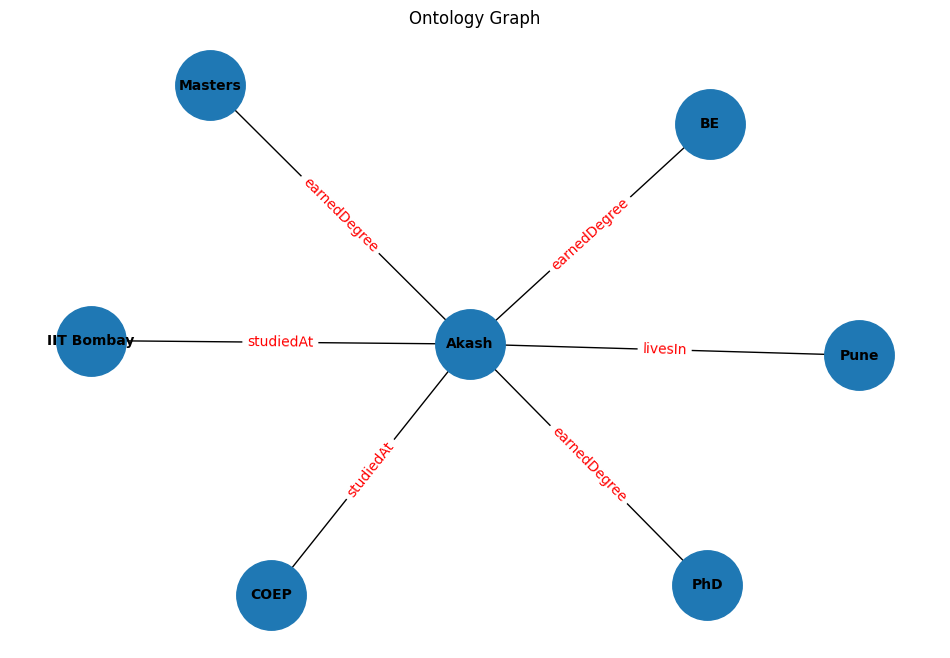

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------
# Ontology extracted from NER
# ---------------------------------------

ontology = {
    "Person": ["Akash"],
    "Location": ["Pune"],
    "Organization": ["COEP", "IIT Bombay"],
    "Degree": ["BE", "Masters", "PhD"]
}

# ---------------------------------------
# Create Graph
# ---------------------------------------

G = nx.DiGraph()

# Person
G.add_node("Akash", type="Person")

# City
G.add_node("Pune", type="Location")

# Organizations
G.add_node("COEP", type="Organization")
G.add_node("IIT Bombay", type="Organization")

# Degrees
G.add_node("BE", type="Degree")
G.add_node("Masters", type="Degree")
G.add_node("PhD", type="Degree")

# ---------------------------------------
# Relationships
# ---------------------------------------

G.add_edge("Akash", "Pune", relation="livesIn")

G.add_edge("Akash", "COEP", relation="studiedAt")
G.add_edge("Akash", "IIT Bombay", relation="studiedAt")

G.add_edge("Akash", "BE", relation="earnedDegree")
G.add_edge("Akash", "Masters", relation="earnedDegree")
G.add_edge("Akash", "PhD", relation="earnedDegree")

# ---------------------------------------
# Draw Ontology
# ---------------------------------------

plt.figure(figsize=(12,8))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.2
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2500
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=25
)

edge_labels = nx.get_edge_attributes(
    G,
    "relation"
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_color="red"
)

plt.title("Ontology Graph")

plt.axis("off")

plt.show()

In [ ]:
!pip install rdflib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 11.3 MB/s eta 0:00:00


In [ ]:
from rdflib import Graph, Namespace, RDF

EX = Namespace("http://example.org/ontology/")

g = Graph()

g.add((EX.Akash, RDF.type, EX.Person))
g.add((EX.Pune, RDF.type, EX.Location))
g.add((EX.COEP, RDF.type, EX.Organization))
g.add((EX.IITBombay, RDF.type, EX.Organization))
g.add((EX.BE, RDF.type, EX.Degree))

g.add((EX.Akash, EX.livesIn, EX.Pune))
g.add((EX.Akash, EX.studiedAt, EX.COEP))
g.add((EX.Akash, EX.studiedAt, EX.IITBombay))
g.add((EX.Akash, EX.earnedDegree, EX.BE))

print(g.serialize(format="turtle"))

@prefix ns1: <http://example.org/ontology/> .

ns1:Akash a ns1:Person ;
    ns1:earnedDegree ns1:BE ;
    ns1:livesIn ns1:Pune ;
    ns1:studiedAt ns1:COEP,
        ns1:IITBombay .

ns1:BE a ns1:Degree .

ns1:COEP a ns1:Organization .

ns1:IITBombay a ns1:Organization .

ns1:Pune a ns1:Location .




In [ ]:
! pip install neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 6.5 MB/s eta 0:00:00
